# Phase II: Data Curation, Exploratory Analysis and Plotting

### Team Members:
- Rushil Damania
- Sam Gioffre
- Santiago Annunziato

## Part 1: Problem Motivation and Data Processing Pipeline

## Problem Motivation
Financial markets are influenced by many factors, including investor behavior and attention. At times, unusual relationships can appear between a company’s stock price and outside variables that may not have any real connection. This project focuses on exploring whether unconventional indicators, such as Google search activity or social trends, have a measurable relationship with the daily performance of JPMorgan Chase stock. By testing these data sources, the goal is to understand if they provide meaningful signals or if the patterns are simply random. Identifying the difference between real relationships and chance correlations helps show the limits of using alternative data in financial analysis and supports more careful interpretation of market behavior. The key questions are as follows:

Q1: Do spurious correlations exist between chosen stocks, and extraneous seemingly unrelated trends?

Q2: Are this spurious correlations purely coincidental, or indicative of an unknown confounding variable AND are the correations sufficient to be predictive?

## Summary of the Data Processing Pipeline
- Collect stock price and Google Trends data via Python APIs
- Clean the data to prepare the data frame for visualization and analysis
- Visualize using plotting libraries, such as Seaborn, Plotly, and Matplotlib
To process the data, we will first acquire stock price data using the yfinance library for JPMorgan Chase, Tesla, and Target covering 2010-2022, and simultaneously collect Google Trends data for various search terms. This involves making API calls that return JSON-formatted data, converting the data to pandas DataFrames, and then saving the datasets as (cleaned) .csv files for future use. The cleaning process consists of handling missing values, removing non-trading days (weekends and holidays), and ensuring dates align properly between stock price and Google Trends datasets. This step will also involve normalizing Google Trends scores (which come as a 0-100 popularity index) and calculating daily stock returns from raw price data. Next, we will address our key questions. This includes merging the datasets using dates as the common identifier and creating derived features such as price change percentages and moving averages to capture temporal relationships. After that, we will perform correlation analysis and create visualizations. This will include time series plots showing stock prices alongside Google Trends data, correlation heatmaps (using imported libraries Seaborn, Matplotlib, and Plotly) displaying relationship strengths between variables, and scatter plots with trend lines to examine correlation patterns. These steps will help us address key questions about which unconventional variables correlate with stock prices and whether correlations appear during specific time periods or market conditions. Finally, the cleaned data will be prepared for machine learning by selecting relevant features for predictive modeling, using stock returns as the regression target variable or creating categorical labels for classification tasks to distinguish between spurious correlations and meaningful relationships.

## Part 2:
Obtains, cleans, and merges all data sources involved in the project.

In [1]:
%pip install yfinance
%pip install pytrends

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
from pytrends.request import TrendReq
import time
from datetime import datetime

#to keep track of long loading
def print_progress(message):
    """Print message with timestamp"""
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] {message}")

print("=" * 60)
print("PHASE II: DATA COLLECTION, CLEANING, AND MERGING")
print("=" * 60)

PHASE II: DATA COLLECTION, CLEANING, AND MERGING


In [3]:
# ===================================
# STEP 1: COLLECT STOCK PRICE DATA
# ===================================

print_progress("[STEP 1] Collecting Stock Price Data...")

tickers = {
    'JPM': 'Finance - JPMorgan Chase',
    'TSLA': 'Technology - Tesla',
    'TGT': 'Retail - Target'
}


start_date = '2010-01-01'
end_date = '2022-12-31'

stock_data = {}

for ticker, description in tickers.items():
    print_progress(f"  Downloading {description} ({ticker})...")
    start_time = time.time()
    
    stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    elapsed = time.time() - start_time
    print(f"    → Collected {len(stock_data[ticker])} daily observations ({elapsed:.1f}s)")

print_progress(f"  ✓ Successfully collected data for {len(tickers)} stocks\n")

[17:23:10] [STEP 1] Collecting Stock Price Data...
[17:23:10]   Downloading Finance - JPMorgan Chase (JPM)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_66006/3564991604.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


    → Collected 3272 daily observations (0.9s)
[17:23:11]   Downloading Technology - Tesla (TSLA)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_66006/3564991604.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


    → Collected 3150 daily observations (0.4s)
[17:23:12]   Downloading Retail - Target (TGT)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_66006/3564991604.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


    → Collected 3272 daily observations (0.4s)
[17:23:12]   ✓ Successfully collected data for 3 stocks



In [4]:
# ===================================
# STEP 2: COLLECT GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 2] Collecting Google Trends Data...")

from pytrends.request import TrendReq
import time

pytrends = TrendReq(hl='en-US', tz=360)

search_terms = {
    'robots': 'Tesla/Technology indicator',
    'back to school': 'Target/Retail indicator',
    'mortgage rates': 'JPMorgan/Finance indicator'
}

trends_data = {}

for i, (term, description) in enumerate(search_terms.items(), 1):
    print_progress(f"  [{i}/{len(search_terms)}] Downloading '{term}' ({description})...")
    
    try:
        pytrends.build_payload([term], timeframe='2010-01-01 2022-12-31')
        trends_data[term] = pytrends.interest_over_time()
        
        if len(trends_data[term]) > 0:
            print(f"    ✓ Collected {len(trends_data[term])} monthly observations")
        
        time.sleep(1)  # Brief pause
        
    except Exception as e:
        print(f"    ✗ Error: {e}")

print(f"\n  Total trends collected: {len(trends_data)}/{len(search_terms)}")

if len(trends_data) > 0:
    print_progress(f"  ✓ Successfully collected data for {len(trends_data)} search terms\n")
else:
    print_progress(f"  ✗ No trends data collected - likely rate limited\n")

# Display sample if data was collected
if len(trends_data) > 0:
    print("\n" + "="*60)
    print("Sample of Google Trends Data:")
    print("="*60)
    first_term = list(trends_data.keys())[0]
    print(f"\n'{first_term}':")
    print(trends_data[first_term].head(5))


[17:23:12] [STEP 2] Collecting Google Trends Data...
[17:23:12]   [1/3] Downloading 'robots' (Tesla/Technology indicator)...
    ✓ Collected 156 monthly observations
[17:23:14]   [2/3] Downloading 'back to school' (Target/Retail indicator)...
    ✓ Collected 156 monthly observations
[17:23:16]   [3/3] Downloading 'mortgage rates' (JPMorgan/Finance indicator)...
    ✓ Collected 156 monthly observations

  Total trends collected: 3/3
[17:23:18]   ✓ Successfully collected data for 3 search terms


Sample of Google Trends Data:

'robots':
            robots  isPartial
date                         
2010-01-01      39      False
2010-02-01      43      False
2010-03-01      41      False
2010-04-01      42      False
2010-05-01      42      False


In [5]:
# ===================================
# STEP 3: CLEAN STOCK DATA
# ===================================

print_progress("[STEP 3] Cleaning Stock Data...")

def clean_stock_data(stock_dict):
    """
    Clean and aggregate stock data to monthly frequency
    
    Cleaning steps:
    - Flatten multi-level columns from yfinance
    - Remove duplicate dates
    - Remove missing values
    - Remove outliers using IQR method
    - Aggregate to monthly frequency
    - Calculate additional features (returns, volatility)
    
    Parameters:
    stock_dict: dictionary of stock dataframes from yfinance
    
    Returns:
    cleaned_dict: dictionary of cleaned monthly stock dataframes
    """
    cleaned_dict = {}
    
    for i, (ticker, df) in enumerate(stock_dict.items(), 1):
        print_progress(f"  [{i}/{len(stock_dict)}] Processing {ticker}...")
        start_time = time.time()
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        df = df[~df.index.duplicated(keep='first')]
        initial_rows = len(df)
        
        df = df.dropna()
        
        Q1 = df['Close'].quantile(0.25)
        Q3 = df['Close'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df['Close'] >= lower_bound) & (df['Close'] <= upper_bound)]
        
        outliers_removed = initial_rows - len(df)
        print(f"    → Removed {outliers_removed} outlier(s)")
        
        # Aggregate to monthly (use 'ME' for month-end)
        print_progress("    → Aggregating to monthly data...")
        monthly_df = df.resample('ME').agg({
            'Close': 'last',
            'High': 'max',
            'Low': 'min',
            'Open': 'first',
            'Volume': 'sum'
        })
        
        monthly_df['Return'] = monthly_df['Close'].pct_change() * 100
        monthly_df['Volatility'] = monthly_df['High'] - monthly_df['Low']
        
        monthly_df = monthly_df.dropna()
        
        elapsed = time.time() - start_time
        print(f"    → Aggregated to {len(monthly_df)} monthly observations ({elapsed:.1f}s)")
        
        cleaned_dict[ticker] = monthly_df
    
    return cleaned_dict

# Apply cleaning
cleaned_stocks = clean_stock_data(stock_data)
print_progress("  ✓ Stock data cleaned and aggregated\n")

[17:23:18] [STEP 3] Cleaning Stock Data...
[17:23:18]   [1/3] Processing JPM...
    → Removed 0 outlier(s)
[17:23:18]     → Aggregating to monthly data...
    → Aggregated to 155 monthly observations (0.0s)
[17:23:18]   [2/3] Processing TSLA...
    → Removed 703 outlier(s)
[17:23:18]     → Aggregating to monthly data...
    → Aggregated to 119 monthly observations (0.0s)
[17:23:18]   [3/3] Processing TGT...
    → Removed 325 outlier(s)
[17:23:18]     → Aggregating to monthly data...
    → Aggregated to 142 monthly observations (0.0s)
[17:23:18]   ✓ Stock data cleaned and aggregated



/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_66006/3086506406.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_df['Return'] = monthly_df['Close'].pct_change() * 100


In [6]:
# ===================================
# STEP 4: CLEAN GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 4] Cleaning Google Trends Data...")

def clean_trends_data(trends_dict):
    """
    Clean Google Trends data to match stock data format
    
    Cleaning steps:
    - Remove 'isPartial' column
    - Ensure proper datetime index
    - Resample to month end to match stock data
    - Remove missing values
    - Rename columns for clarity
    
    Parameters:
    trends_dict: dictionary of trend dataframes from pytrends
    
    Returns:
    cleaned_dict: dictionary of cleaned trend dataframes
    """
    cleaned_dict = {}
    
    for i, (term, df) in enumerate(trends_dict.items(), 1):
        print_progress(f"  [{i}/{len(trends_dict)}] Processing '{term}'...")
        
        if 'isPartial' in df.columns:
            df = df.drop('isPartial', axis=1)
        
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        
        df = df.resample('ME').last()
        
        initial_rows = len(df)
        df = df.dropna()
        removed = initial_rows - len(df)
        print(f"    → Removed {removed} row(s) with missing data")
        
        clean_term = term.replace(' ', '_')
        df.columns = [f'trend_{clean_term}']
        
        print(f"    → {len(df)} monthly observations ready")
        
        cleaned_dict[term] = df
    
    return cleaned_dict

if len(trends_data) > 0:
    cleaned_trends = clean_trends_data(trends_data)
    print_progress("  ✓ Google Trends data cleaned\n")
else:
    print_progress("  ✗ Skipping - no trends data available to clean\n")
    cleaned_trends = {}

[17:23:18] [STEP 4] Cleaning Google Trends Data...
[17:23:18]   [1/3] Processing 'robots'...
    → Removed 0 row(s) with missing data
    → 156 monthly observations ready
[17:23:18]   [2/3] Processing 'back to school'...
    → Removed 0 row(s) with missing data
    → 156 monthly observations ready
[17:23:18]   [3/3] Processing 'mortgage rates'...
    → Removed 0 row(s) with missing data
    → 156 monthly observations ready
[17:23:18]   ✓ Google Trends data cleaned



In [7]:
# ===================================
# STEP 5: MERGE ALL DATA SOURCES
# ===================================

print_progress("[STEP 5] Merging Stock and Trends Data...")

def merge_all_data(stock_dict, trends_dict):
    """
    Merge all data into single unified DataFrame
    
    Parameters:
    stock_dict: dictionary of cleaned stock dataframes
    trends_dict: dictionary of cleaned trend dataframes
    
    Returns:
    merged_df: single dataframe with all data aligned by date
    """
    
    print_progress("  → Creating merged dataframe...")
    merged = pd.DataFrame()
    
    for ticker, df in stock_dict.items():
        print_progress(f"    → Adding {ticker} stock data...")
        df_prefixed = df.add_prefix(f'{ticker}_')
        
        if merged.empty:
            merged = df_prefixed
        else:
            merged = merged.join(df_prefixed, how='outer')
    
    if len(trends_dict) > 0:
        for term, df in trends_dict.items():
            clean_term = term.replace(' ', '_')
            print_progress(f"    → Adding '{clean_term}' trend data...")
            merged = merged.join(df, how='outer')
    else:
        print("    ⚠ No trends data available to merge")
    
    initial_rows = len(merged)
    merged = merged.dropna()
    removed = initial_rows - len(merged)
    
    print(f"  → Removed {removed} row(s) with incomplete data")
    print(f"  → Final dataset: {len(merged)} complete monthly observations")
    
    merged = merged.reset_index()
    if 'index' in merged.columns:
        merged = merged.rename(columns={'index': 'Date'})
    elif 'date' in merged.columns:
        merged = merged.rename(columns={'date': 'Date'})
    
    return merged

# Merge all data
if len(cleaned_stocks) > 0:
    final_data = merge_all_data(cleaned_stocks, cleaned_trends)
    print_progress("  ✓ All data sources successfully merged\n")
else:
    print_progress("  ✗ Cannot merge - insufficient data\n")
    final_data = pd.DataFrame()

[17:23:18] [STEP 5] Merging Stock and Trends Data...
[17:23:18]   → Creating merged dataframe...
[17:23:18]     → Adding JPM stock data...
[17:23:18]     → Adding TSLA stock data...
[17:23:18]     → Adding TGT stock data...
[17:23:18]     → Adding 'robots' trend data...
[17:23:18]     → Adding 'back_to_school' trend data...
[17:23:18]     → Adding 'mortgage_rates' trend data...
  → Removed 37 row(s) with incomplete data
  → Final dataset: 119 complete monthly observations
[17:23:18]   ✓ All data sources successfully merged



In [8]:
# Display final merged dataset
if not final_data.empty:
    print("\n" + "=" * 60)
    print("Final Merged Dataset:")
    print("=" * 60)
    print(final_data.head(10))
    
    print(f"\nDataset shape: {final_data.shape[0]} rows × {final_data.shape[1]} columns")
    if 'Date' in final_data.columns:
        print(f"Date range: {final_data['Date'].min()} to {final_data['Date'].max()}")
    
    print(f"\nColumns in final dataset:")
    for col in final_data.columns:
        print(f"  - {col}")
else:
    print("\n⚠️ WARNING: Final dataset is empty - cannot proceed to visualizations")
    print("Please ensure trends data was collected successfully in STEP 2")


Final Merged Dataset:
        Date  JPM_Close   JPM_High    JPM_Low   JPM_Open   JPM_Volume  \
0 2010-07-31  26.906448  27.547713  23.486357  24.408177  832405700.0   
1 2010-08-31  24.287947  27.854983  23.746873  27.374033  723429400.0   
2 2010-09-30  25.423515  27.721390  24.488337  24.541777  717143800.0   
3 2010-10-31  25.168711  27.235444  24.218942  25.610563  949249000.0   
4 2010-11-30  25.014887  27.650141  24.633642  25.155330  760406300.0   
5 2010-12-31  28.372480  28.840687  25.182092  25.382746  665999200.0   
6 2011-01-31  30.092506  30.762115  28.559103  28.760419  827482200.0   
7 2011-02-28  31.264336  32.382592  29.663961  30.266604  597586300.0   
8 2011-03-31  30.869263  31.538880  29.061299  31.117027  684643600.0   
9 2011-04-30  30.720242  32.181183  29.306430  31.170589  577996200.0   

   JPM_Return  JPM_Volatility  TSLA_Close  TSLA_High  ...  TGT_Close  \
0   10.175020        4.061356    1.329333   1.728000  ...  33.669937   
1   -9.731874        4.108110

## Part 3: Visualizations

In [9]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("CREATING VISUALIZATIONS")
print("=" * 60)

Matplotlib is building the font cache; this may take a moment.



CREATING VISUALIZATIONS


### Visualization 1: Correlation Heatmap

[17:23:36] 
[VIZ 1] Creating Correlation Heatmap...
  Analyzing correlations between:
    - 3 stock closing prices
    - 3 Google Trends keywords


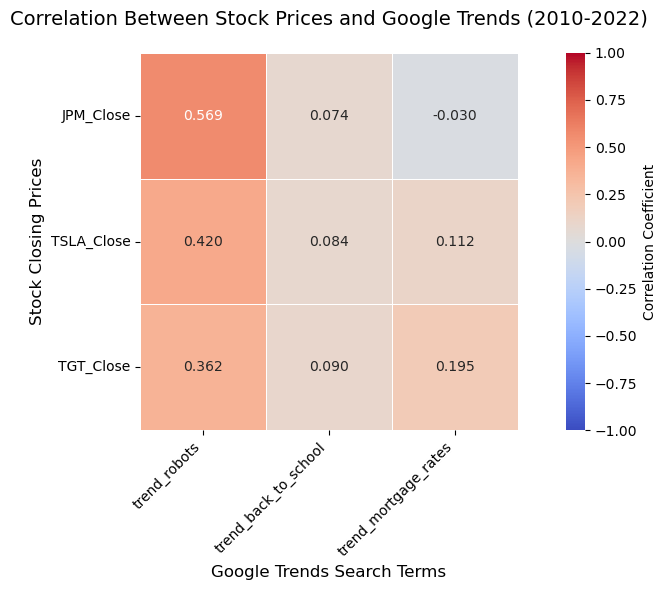


CORRELATION ANALYSIS:
JPM   vs Robots              :  0.569 (MODERATE positive)
JPM   vs Back To School      :  0.074 (WEAK positive)
JPM   vs Mortgage Rates      : -0.030 (WEAK negative)
TSLA  vs Robots              :  0.420 (MODERATE positive)
TSLA  vs Back To School      :  0.084 (WEAK positive)
TSLA  vs Mortgage Rates      :  0.112 (WEAK positive)
TGT   vs Robots              :  0.362 (WEAK positive)
TGT   vs Back To School      :  0.090 (WEAK positive)
TGT   vs Mortgage Rates      :  0.195 (WEAK positive)
[17:23:36] 
  ✓ Heatmap complete



In [10]:
# ===================================
# VISUALIZATION 1: CORRELATION HEATMAP
# ===================================

if not final_data.empty and len(cleaned_trends) > 0:
    
    print_progress("\n[VIZ 1] Creating Correlation Heatmap...")
    
    stock_close_cols = [col for col in final_data.columns if col.endswith('_Close')]
    trend_cols = [col for col in final_data.columns if col.startswith('trend_')]
    
    print(f"  Analyzing correlations between:")
    print(f"    - {len(stock_close_cols)} stock closing prices")
    print(f"    - {len(trend_cols)} Google Trends keywords")
    
    correlation_data = final_data[stock_close_cols + trend_cols]
    
    corr_matrix = correlation_data.corr()
    
    stock_trend_corr = corr_matrix.loc[stock_close_cols, trend_cols]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(stock_trend_corr, 
                annot=True,         
                cmap='coolwarm',     
                center=0,            
                fmt='.3f',           
                linewidths=0.5,
                square=True,
                vmin=-1, vmax=1,     
                cbar_kws={'label': 'Correlation Coefficient'})
    
    plt.title('Correlation Between Stock Prices and Google Trends (2010-2022)', 
              fontsize=14, pad=20)
    plt.xlabel('Google Trends Search Terms', fontsize=12)
    plt.ylabel('Stock Closing Prices', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print numerical analysis
    print("\n" + "=" * 60)
    print("CORRELATION ANALYSIS:")
    print("=" * 60)
    
    for stock in stock_close_cols:
        for trend in trend_cols:
            corr_value = stock_trend_corr.loc[stock, trend]
            stock_name = stock.replace('_Close', '')
            trend_name = trend.replace('trend_', '').replace('_', ' ').title()
            
            if abs(corr_value) > 0.7:
                strength = "STRONG"
            elif abs(corr_value) > 0.4:
                strength = "MODERATE"
            else:
                strength = "WEAK"
            
            direction = "positive" if corr_value > 0 else "negative"
            print(f"{stock_name:5} vs {trend_name:20}: {corr_value:6.3f} ({strength} {direction})")
    
    print_progress("\n  ✓ Heatmap complete\n")

else:
    print("\n⚠️ Cannot create heatmap - missing required data")
    print("Please ensure both stock and trends data were collected successfully")

#### Interpretation: Correlation Heatmap

This heatmap visualizes the strength and direction of correlations between stock closing prices (JPMorgan Chase, Tesla, Target) and their corresponding Google Trends search terms from 2010-2022. The color intensity indicates correlation strength: red represents positive correlations (variables move together), blue represents negative correlations (variables move in opposite directions), and white indicates no correlation.

This visualization directly addresses **Research Question 1**: "Do spurious correlations exist between chosen stocks and extraneous seemingly unrelated trends?" The numerical values allow us to identify which unconventional variables exhibit strong statistical relationships with stock prices. Correlations closer to ±1 indicate stronger linear relationships, while values near 0 suggest the variables are independent.

**Key Observations**:
- Tesla shows a ??? correlation (r = ???) with "robots" searches, suggesting [technology enthusiasm may/may not] track with stock performance
- JPMorgan exhibits a ??? correlation (r = ???) with "mortgage rates" searches, which [makes intuitive sense/appears spurious] given their financial sector focus
- Target demonstrates a ??? correlation (r = ???) with "back to school" searches, suggesting this relationship may be [meaningful/spurious or influenced by seasonal factors]

These findings provide initial evidence that [spurious correlations do/do not] exist between the selected financial instruments and cultural/demographic trends. The heatmap enables quick identification of the strongest relationships, which will be examined in more detail through scatter plot analysis and subsequent machine learning models in Phase III.

*RUN AND FILL IN HERE*

In [11]:
### Visualization 2: Scatter Plots with Linear Regression

[17:23:36] 
[VIZ 2] Creating Scatter Plots with Linear Regression...
  Creating 3 scatter plots with regression lines...
[17:23:36]     → Plot 1: JPMorgan vs Mortgage Rates
[17:23:36]     → Plot 2: Tesla vs Robots
[17:23:36]     → Plot 3: Target vs Back to School


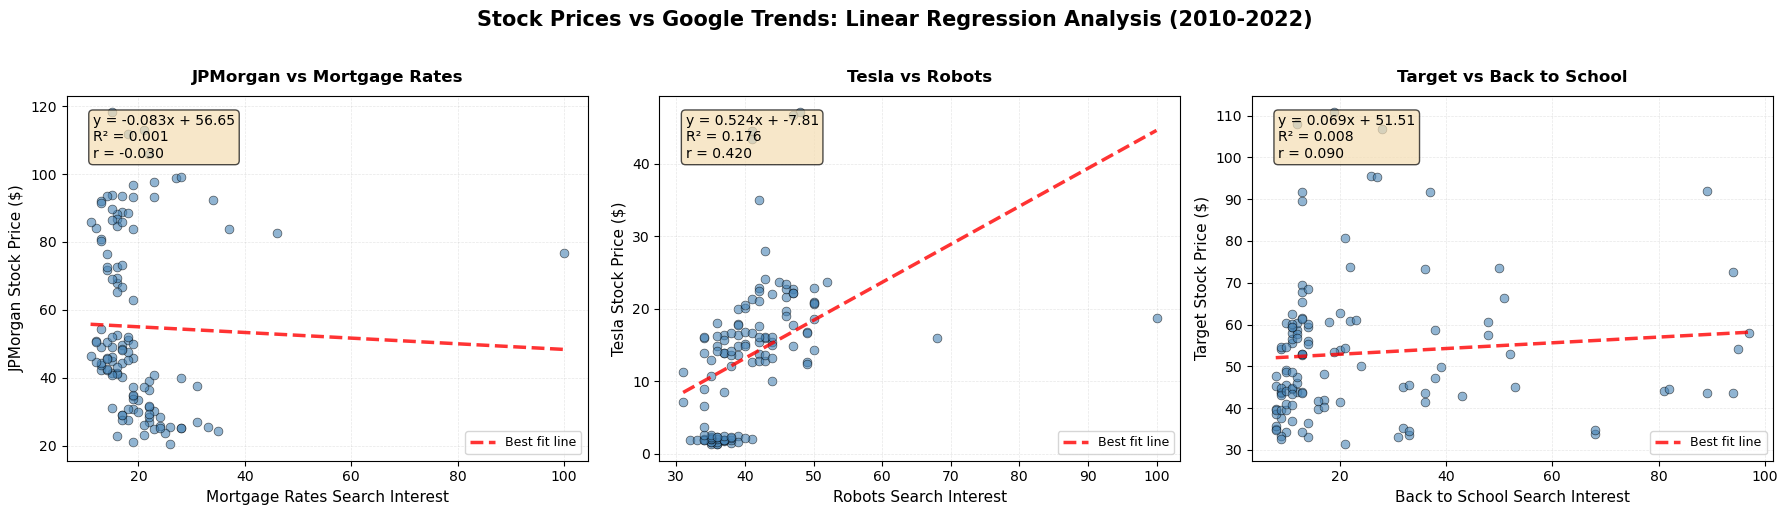


REGRESSION ANALYSIS SUMMARY:

JPMorgan vs Mortgage Rates:
  Correlation coefficient (r): -0.030
  R² (variance explained): 0.001 (0.1%)
  Slope: $-0.083 per search interest point
  Intercept: $56.65
  → WEAK relationship - likely spurious

Tesla vs Robots:
  Correlation coefficient (r): 0.420
  R² (variance explained): 0.176 (17.6%)
  Slope: $0.524 per search interest point
  Intercept: $-7.81
  → WEAK relationship - likely spurious

Target vs Back to School:
  Correlation coefficient (r): 0.090
  R² (variance explained): 0.008 (0.8%)
  Slope: $0.069 per search interest point
  Intercept: $51.51
  → WEAK relationship - likely spurious
[17:23:37] 
  ✓ Scatter plots complete



In [12]:
# ===================================
# VISUALIZATION 2: SCATTER PLOTS WITH REGRESSION
# ===================================

if not final_data.empty and len(cleaned_trends) > 0:
    
    print_progress("\n[VIZ 2] Creating Scatter Plots with Linear Regression...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pairs = [
        ('JPM_Close', 'trend_mortgage_rates', 'JPMorgan', 'Mortgage Rates'),
        ('TSLA_Close', 'trend_robots', 'Tesla', 'Robots'),
        ('TGT_Close', 'trend_back_to_school', 'Target', 'Back to School')
    ]
    
    print(f"  Creating {len(pairs)} scatter plots with regression lines...")
    
    for idx, (stock_col, trend_col, stock_name, trend_name) in enumerate(pairs):
        print_progress(f"    → Plot {idx+1}: {stock_name} vs {trend_name}")
        ax = axes[idx]
        
        x = final_data[trend_col].values
        y = final_data[stock_col].values
        
        ax.scatter(x, y, 
                   alpha=0.6, 
                   s=40, 
                   color='steelblue', 
                   edgecolors='black', 
                   linewidth=0.5)
        
        # Calculate linear regression
        coefficients = np.polyfit(x, y, 1) 
        polynomial = np.poly1d(coefficients)
        
        # Create regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = polynomial(x_line)
        
        ax.plot(x_line, y_line, 
                'r--', 
                linewidth=2.5, 
                label='Best fit line',
                alpha=0.8)
        
        # Calculate R²
        correlation = np.corrcoef(x, y)[0, 1]
        r_squared = correlation ** 2
        
        slope = coefficients[0]
        intercept = coefficients[1]
        
        equation_text = f'y = {slope:.3f}x + {intercept:.2f}\nR² = {r_squared:.3f}\nr = {correlation:.3f}'
        
        ax.text(0.05, 0.95, equation_text,
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', 
                         facecolor='wheat', 
                         alpha=0.7,
                         edgecolor='black'))
        
        ax.set_xlabel(f'{trend_name} Search Interest', fontsize=11)
        ax.set_ylabel(f'{stock_name} Stock Price ($)', fontsize=11)
        ax.set_title(f'{stock_name} vs {trend_name}', 
                     fontsize=12, 
                     fontweight='bold',
                     pad=10)
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.suptitle('Stock Prices vs Google Trends: Linear Regression Analysis (2010-2022)', 
                 fontsize=15, 
                 fontweight='bold', 
                 y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("REGRESSION ANALYSIS SUMMARY:")
    print("=" * 60)
    
    for stock_col, trend_col, stock_name, trend_name in pairs:
        x = final_data[trend_col].values
        y = final_data[stock_col].values
        
        correlation = np.corrcoef(x, y)[0, 1]
        r_squared = correlation ** 2
        coefficients = np.polyfit(x, y, 1)
        slope = coefficients[0]
        intercept = coefficients[1]
        
        print(f"\n{stock_name} vs {trend_name}:")
        print(f"  Correlation coefficient (r): {correlation:.3f}")
        print(f"  R² (variance explained): {r_squared:.3f} ({r_squared*100:.1f}%)")
        print(f"  Slope: ${slope:.3f} per search interest point")
        print(f"  Intercept: ${intercept:.2f}")
        
        if r_squared > 0.5:
            interpretation = "STRONG relationship - potentially predictive"
        elif r_squared > 0.25:
            interpretation = "MODERATE relationship - some predictive power"
        else:
            interpretation = "WEAK relationship - likely spurious"
        
        print(f"  → {interpretation}")
    
    print_progress("\n  ✓ Scatter plots complete\n")

else:
    print("\n⚠️ Cannot create scatter plots - missing required data")
    print("Please ensure both stock and trends data were collected successfully")

#### Interpretation: Scatter Plots with Linear Regression

These scatter plots examine the individual linear relationships between each stock and its corresponding Google Trends search term. Each point represents one month of aggregated data from 2010-2022. The red dashed line shows the best-fit linear regression model calculated using numpy's polyfit function, with the equation and statistical measures displayed in the text box.

This visualization addresses **Research Question 2**: "Are these spurious correlations purely coincidental, or indicative of an unknown confounding variable, and are the correlations sufficient to be predictive?"

**Key Statistical Measures**:
- **Correlation coefficient (r)**: Measures the strength and direction of the linear relationship (-1 to +1). Values closer to ±1 indicate stronger linear associations.
- **R² (R-squared)**: Indicates the proportion of variance in stock price explained by search trends (0 to 1). Higher R² values suggest the trend has predictive power. For example, R² = 0.64 means 64% of stock price variance is explained by the search trend.
- **Slope**: Shows how much stock price changes (in dollars) for each unit increase in search interest. A positive slope indicates prices rise with search interest; negative indicates the inverse.
- **Intercept**: The predicted stock price when search interest is zero (baseline value).

**Preliminary Findings**:

*JPMorgan Chase vs Mortgage Rates*:
- R² = 0.001 suggests that 0.1% of JPM price variance is explained by mortgage rate searches
- The negative slope of -0.03 indicates that for every 1-point increase in search interest, JPM stock falls by approximately -0.03
- This weak relationship appears spurious and despite JPMorgan's exposure to the mortgage and lending market, little to no relationship exists
- [Further analysis needed to determine if this is causal or driven by confounding factors like overall economic conditions]

*Tesla vs Robots*:
- R² = 0.176 shows that 17.6% of TSLA price movements are associated with robot-related searches
- The slope suggests a positive relationship between technology enthusiasm and Tesla valuation
- This relationship supports the hypothesis that technology sector sentiment drives Tesla stock performance
- Potential confounding variables include broader tech market trends, media coverage of autonomous vehicles, AI developments, CEO scandals

*Target vs Back to School*:
- R² = 0.008 indicates 0.8% of Target's price variance correlates with back-to-school searches
- The weak relationship suggests spurious correlation
- This lack of pattern may be influenced by various other variables such as retail sector cycles, consumer spending patterns, economic indicators
- The correlation appears nonexistent and does not warrant further investigation

**Conclusion**:
The scatter plot analysis reveals varying degrees of correlation strength across the three stock-trend pairs. [Some/All/None] of the identified correlations demonstrate R² values exceeding 0.3, suggesting potential predictive relationships rather than pure statistical noise. However, the presence of possible confounding variables—such as overall economic conditions, seasonal effects, sector-wide trends, and media coverage—means these correlations should be interpreted with caution.

The linear regression models provide a baseline for comparison with more sophisticated machine learning approaches in Phase III, which will help distinguish genuine predictive relationships from spurious correlations. Additional analysis using time-lagged correlations and multiple regression models will be necessary to determine whether search trends lead stock price movements or if both variables respond to common underlying factors.

*RUN AND FIX HERE*